In [1]:
!pip install -q monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.4 MB/s eta 0:00:00


In [2]:
import torch, monai
print(torch.cuda.is_available())
print(monai.__version__)

True
1.6.0


In [3]:
!kaggle datasets download -d rj1007/imagecas
!unzip -q imagecas.zip -d /content/imagecas_data

Dataset URL: https://www.kaggle.com/datasets/rj1007/imagecas
License(s): apache-2.0
100% 5.04G/5.04G [00:29<00:00, 182MB/s]



In [4]:
!ls /content/imagecas_data | head

10.img.nii
10.label.nii
11.img.nii
11.label.nii
12.img.nii
12.label.nii
13.img.nii
13.label.nii
14.img.nii
14.label.nii


In [8]:
data_dicts = [
    {
        "image": ".../dia_0.nii",
        "label": ".../label.nii"
    }
]

In [9]:
print(len(data_dicts))

1


In [10]:
import os

images = sorted([f for f in os.listdir("/content/imagecas_data") if f.endswith(".img.nii")])
labels = sorted([f for f in os.listdir("/content/imagecas_data") if f.endswith(".label.nii")])

print("Images:", len(images))
print("Labels:", len(labels))
print(images[:5])
print(labels[:5])

Images: 60
Labels: 60
['1.img.nii', '10.img.nii', '11.img.nii', '12.img.nii', '13.img.nii']
['1.label.nii', '10.label.nii', '11.label.nii', '12.label.nii', '13.label.nii']


In [11]:
import os

img_dir = "/content/imagecas_data/1.img.nii"
lbl_dir = "/content/imagecas_data/1.label.nii"

print(os.listdir(img_dir))
print(os.listdir(lbl_dir))

['diao_0.nii']
['label.nii']


In [12]:
import os

data_dicts = []

for item in sorted(os.listdir("/content/imagecas_data")):
    if item.endswith(".img.nii"):

        patient_id = item.replace(".img.nii", "")

        img_folder = os.path.join("/content/imagecas_data", item)
        lbl_folder = os.path.join("/content/imagecas_data", f"{patient_id}.label.nii")

        img_file = os.path.join(img_folder, os.listdir(img_folder)[0])
        lbl_file = os.path.join(lbl_folder, "label.nii")

        data_dicts.append({
            "image": img_file,
            "label": lbl_file
        })

print("Patients found:", len(data_dicts))
print(data_dicts[0])
print(data_dicts[-1])

Patients found: 60
{'image': '/content/imagecas_data/1.img.nii/diao_0.nii', 'label': '/content/imagecas_data/1.label.nii/label.nii'}
{'image': '/content/imagecas_data/9.img.nii/diao_0.nii', 'label': '/content/imagecas_data/9.label.nii/label.nii'}


In [13]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    data_dicts,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 48
Val: 12


In [14]:
!pip install -q monai nibabel

In [15]:
import monai
print(monai.__version__)

1.6.0


In [16]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    EnsureTyped,
)

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 64),
        pos=1,
        neg=1,
        num_samples=4,
    ),

    EnsureTyped(keys=["image", "label"]),
])

In [17]:
sample = train_transforms(train_files[0])

print(type(sample))
print(len(sample))

for i, s in enumerate(sample):
    print(i, s["image"].shape, s["label"].sum())

<class 'list'>
4
0 torch.Size([1, 128, 128, 64]) metatensor(0.)
1 torch.Size([1, 128, 128, 64]) metatensor(0.)
2 torch.Size([1, 128, 128, 64]) metatensor(4014.)
3 torch.Size([1, 128, 128, 64]) metatensor(22591.)


In [18]:
for i, s in enumerate(sample):
    voxels = s["label"].sum().item()
    print(i, voxels)

0 0.0
1 0.0
2 4014.0
3 22591.0


In [19]:
from monai.data import Dataset, DataLoader

train_ds = Dataset(
    data=train_files,
    transform=train_transforms
)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2
)

In [20]:
batch = next(iter(train_loader))

print(type(batch))
print(batch.keys())

print(batch["image"].shape)
print(batch["label"].shape)

<class 'dict'>
dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])
torch.Size([4, 1, 128, 128, 64])
torch.Size([4, 1, 128, 128, 64])


In [21]:
labels = batch["label"]

print("Positive voxels:", labels.sum().item())
print("Total voxels:", labels.numel())
print("Percent:", 100 * labels.sum().item() / labels.numel())

Positive voxels: 28350.0
Total voxels: 4194304
Percent: 0.6759166717529297


In [22]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    EnsureTyped,
)

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
    ),

    EnsureTyped(keys=["image", "label"]),
])

In [23]:
val_ds = Dataset(
    data=val_files,
    transform=val_transforms
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print("Validation loader created")

Validation loader created


In [24]:
batch = next(iter(val_loader))

print(batch["image"].shape)
print(batch["label"].shape)

torch.Size([1, 1, 512, 512, 275])
torch.Size([1, 1, 512, 512, 275])


In [25]:
import torch
from monai.networks.nets import UNet

device = torch.device("cuda")

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
).to(device)

print("Model on:", device)

Model on: cuda


In [26]:
batch = next(iter(train_loader))

images = batch["image"].to(device)

with torch.no_grad():
    outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([4, 1, 128, 128, 64])
Output: torch.Size([4, 1, 128, 128, 64])


In [27]:
from monai.losses import DiceFocalLoss
import torch

loss_function = DiceFocalLoss(
    sigmoid=True,
    gamma=2.0
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss and optimizer created")

Loss and optimizer created


In [28]:
batch = next(iter(train_loader))

images = batch["image"].to(device)
labels = batch["label"].to(device)

optimizer.zero_grad()

outputs = model(images)

loss = loss_function(outputs, labels)

print("Loss:", loss.item())

loss.backward()
optimizer.step()

print("One training step completed!")

Loss: 1.2600677013397217
One training step completed!


In [29]:
model.train()

epoch_loss = 0

for step, batch in enumerate(train_loader):

    images = batch["image"].to(device)
    labels = batch["label"].to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = loss_function(outputs, labels)

    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

    if step % 5 == 0:
        print(f"Step {step}/{len(train_loader)} Loss={loss.item():.4f}")

print("Average Epoch Loss:", epoch_loss / len(train_loader))

Step 0/48 Loss=1.2502
Step 5/48 Loss=1.2061
Step 10/48 Loss=1.2021
Step 15/48 Loss=1.1853
Step 20/48 Loss=1.1755
Step 25/48 Loss=1.1770
Step 30/48 Loss=1.1605
Step 35/48 Loss=1.1661
Step 40/48 Loss=1.1594
Step 45/48 Loss=1.1475
Average Epoch Loss: 1.177193860212962


In [30]:
for epoch in range(10):

    model.train()
    epoch_loss = 0

    for batch in train_loader:

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch {epoch+1}/10 "
        f"Loss={epoch_loss/len(train_loader):.4f}"
    )

Epoch 1/10 Loss=1.1236
Epoch 2/10 Loss=1.0957
Epoch 3/10 Loss=1.0753
Epoch 4/10 Loss=1.0609
Epoch 5/10 Loss=1.0481
Epoch 6/10 Loss=1.0399
Epoch 7/10 Loss=1.0290
Epoch 8/10 Loss=1.0237
Epoch 9/10 Loss=1.0149
Epoch 10/10 Loss=1.0121


In [33]:
batch = next(iter(val_loader))

print(batch["image"].shape)


torch.Size([1, 1, 512, 512, 275])


In [34]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    CenterSpatialCropd,
    EnsureTyped,
)

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    CropForegroundd(
        keys=["image", "label"],
        source_key="image",
    ),

    CenterSpatialCropd(
        keys=["image", "label"],
        roi_size=(128,128,64)
    ),

    EnsureTyped(keys=["image", "label"]),
])

In [35]:
val_ds
val_loader

In [36]:
batch = next(iter(val_loader))
print(batch["image"].shape)

torch.Size([1, 1, 512, 512, 275])


In [37]:
from monai.data import Dataset, DataLoader

val_ds = Dataset(
    data=val_files,
    transform=val_transforms
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False
)

print("Validation loader recreated")

Validation loader recreated


In [38]:
batch = next(iter(val_loader))

print(batch["image"].shape)
print(batch["label"].shape)

torch.Size([1, 1, 128, 128, 64])
torch.Size([1, 1, 128, 128, 64])


In [40]:
model.eval()

with torch.no_grad():

    batch = next(iter(val_loader))

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    pred = model(image)

print(pred.shape)

torch.Size([1, 1, 128, 128, 64])


In [41]:
pred_mask = (torch.sigmoid(pred) > 0.5).float()

print("Prediction voxels:", pred_mask.sum().item())
print("Label voxels:", label.sum().item())

Prediction voxels: 15187.0
Label voxels: 11459.0


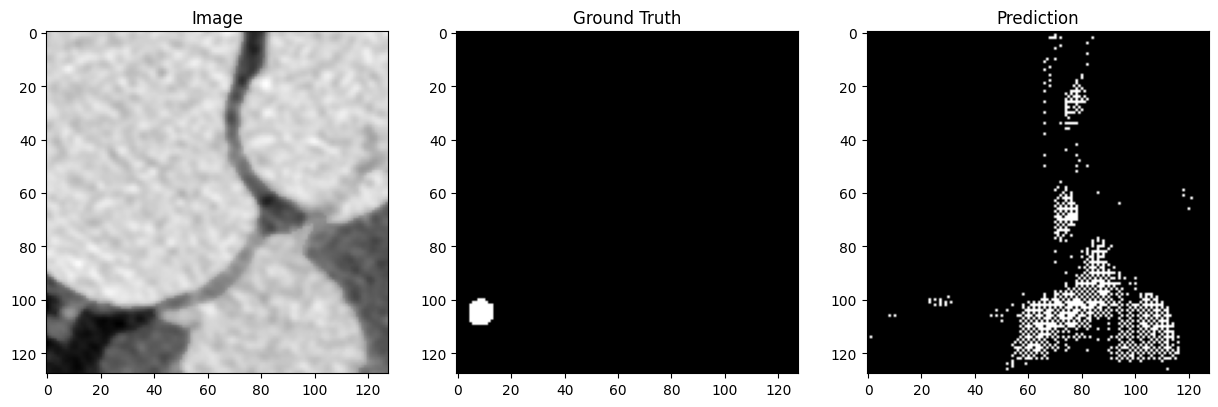

In [42]:
import matplotlib.pyplot as plt

pred_mask = (torch.sigmoid(pred) > 0.5).float()

slice_idx = 32

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(label[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Prediction")

plt.show()

In [43]:
import numpy as np

label_np = label[0,0].cpu().numpy()

areas = [label_np[:,:,i].sum() for i in range(label_np.shape[2])]

best_slice = np.argmax(areas)

print("Best slice:", best_slice)
print("Pixels:", areas[best_slice])

Best slice: 63
Pixels: 1145.0


In [45]:
slice_idx = best_slice

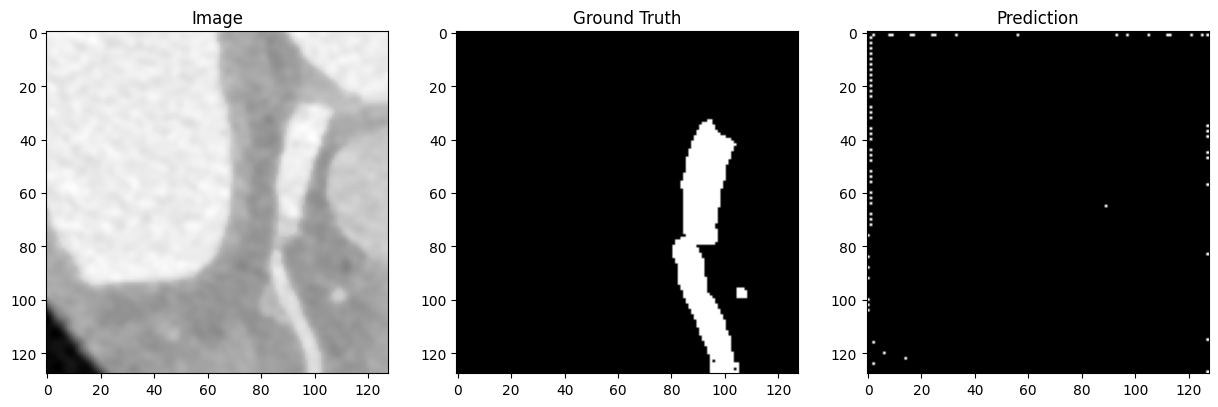

In [46]:
import matplotlib.pyplot as plt

pred_mask = (torch.sigmoid(pred) > 0.5).float()

slice_idx = 63

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(label[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask[0,0,:,:,slice_idx].cpu(), cmap="gray")
plt.title("Prediction")

plt.show()

In [47]:
pred_mask = (torch.sigmoid(pred) > 0.5).float()

intersection = (pred_mask * label).sum()

dice = (2 * intersection) / (
    pred_mask.sum() + label.sum() + 1e-8
)

print("Dice:", dice.item())

Dice: 0.049238160252571106


In [48]:
model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    pred = torch.sigmoid(model(image))
    pred = (pred > 0.5).float()

    intersection = (pred * label).sum()
    dice = (2 * intersection) / (pred.sum() + label.sum() + 1e-8)

print("Train Dice:", dice.item())

Train Dice: 0.40756452083587646


In [49]:
print(len(train_loader))
print(len(val_loader))

48
12


In [50]:
next(iter(val_loader))["label"].sum()

metatensor(11459.)

In [51]:
torch.save(model.state_dict(), "imagecas_epoch10.pth")

In [52]:
max_epochs = 10

In [53]:
max_epochs = 50

In [54]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in val_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

val_dice = sum(dice_scores) / len(dice_scores)

print(
    f"Epoch {epoch+1} "
    f"Loss={epoch_loss:.4f} "
    f"Val Dice={val_dice:.4f}"
)

Epoch 10 Loss=48.5792 Val Dice=0.0444


In [56]:
max_epochs = 50

for epoch in range(max_epochs):

    model.train()

    epoch_loss = 0

    for batch in train_loader:

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    print(
        f"Epoch {epoch+1}/{max_epochs} "
        f"Loss={epoch_loss:.4f}"
    )

Epoch 1/50 Loss=1.0033
Epoch 2/50 Loss=0.9949
Epoch 3/50 Loss=0.9897
Epoch 4/50 Loss=0.9838
Epoch 5/50 Loss=0.9898
Epoch 6/50 Loss=0.9714
Epoch 7/50 Loss=0.9632
Epoch 8/50 Loss=0.9716
Epoch 9/50 Loss=0.9563
Epoch 10/50 Loss=0.9585
Epoch 11/50 Loss=0.9537
Epoch 12/50 Loss=0.9567
Epoch 13/50 Loss=0.9503
Epoch 14/50 Loss=0.9443
Epoch 15/50 Loss=0.9354
Epoch 16/50 Loss=0.9396
Epoch 17/50 Loss=0.9233
Epoch 18/50 Loss=0.9354
Epoch 19/50 Loss=0.9215
Epoch 20/50 Loss=0.9075
Epoch 21/50 Loss=0.9002
Epoch 22/50 Loss=0.8984
Epoch 23/50 Loss=0.8976
Epoch 24/50 Loss=0.8956
Epoch 25/50 Loss=0.8797
Epoch 26/50 Loss=0.8679
Epoch 27/50 Loss=0.8642
Epoch 28/50 Loss=0.8735
Epoch 29/50 Loss=0.8609
Epoch 30/50 Loss=0.8436
Epoch 31/50 Loss=0.8320
Epoch 32/50 Loss=0.8080
Epoch 33/50 Loss=0.8355
Epoch 34/50 Loss=0.7890
Epoch 35/50 Loss=0.7960
Epoch 36/50 Loss=0.7850
Epoch 37/50 Loss=0.7860
Epoch 38/50 Loss=0.7432
Epoch 39/50 Loss=0.7757
Epoch 40/50 Loss=0.7429
Epoch 41/50 Loss=0.7453
Epoch 42/50 Loss=0.7451
E

In [57]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in val_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

print("Mean Validation Dice:", sum(dice_scores)/len(dice_scores))

Mean Validation Dice: 0.2095049357934234


In [58]:
model.eval()

with torch.no_grad():

    batch = next(iter(val_loader))

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    pred = torch.sigmoid(model(image))
    pred = (pred > 0.5).float()

print("Prediction voxels:", pred.sum())
print("Label voxels:", label.sum())

Prediction voxels: metatensor(5225., device='cuda:0')
Label voxels: metatensor(11459., device='cuda:0')


In [59]:
model.eval()

with torch.no_grad():

    batch = next(iter(val_loader))

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    pred = torch.sigmoid(model(image))
    pred = (pred > 0.5).float()

image = image.cpu()[0,0]
label = label.cpu()[0,0]
pred  = pred.cpu()[0,0]

slice_idx = label.sum((0,1)).argmax().item()

print("Best slice:", slice_idx)
print("GT pixels:", label[:,:,slice_idx].sum())
print("Pred pixels:", pred[:,:,slice_idx].sum())

Best slice: 63
GT pixels: metatensor(1145.)
Pred pixels: metatensor(439.)


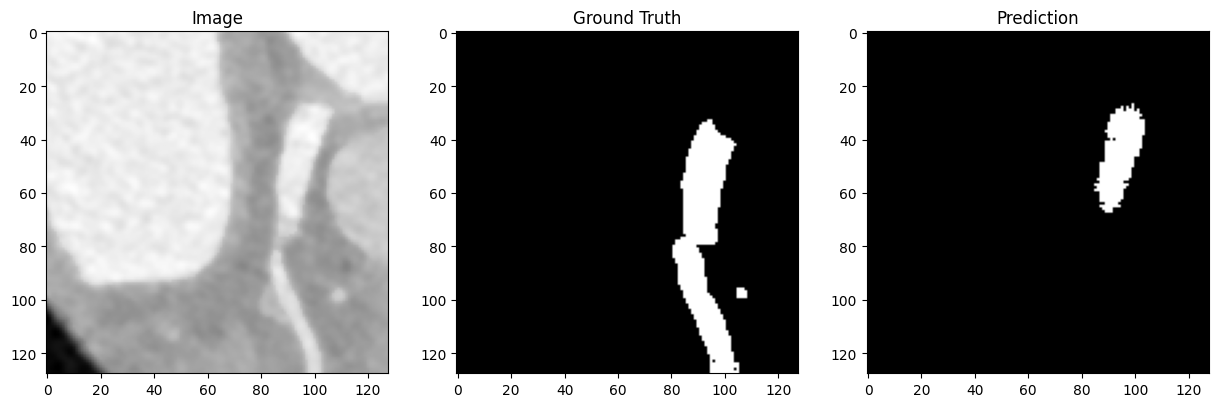

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(image[:,:,slice_idx], cmap="gray")
plt.title("Image")

plt.subplot(132)
plt.imshow(label[:,:,slice_idx], cmap="gray")
plt.title("Ground Truth")

plt.subplot(133)
plt.imshow(pred[:,:,slice_idx], cmap="gray")
plt.title("Prediction")

plt.show()

In [61]:
max_epochs = 25

for epoch in range(max_epochs):

    model.train()

    epoch_loss = 0

    for batch in train_loader:

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch {epoch+1}/25 "
        f"Loss={epoch_loss/len(train_loader):.4f}"
    )

Epoch 1/25 Loss=0.6884
Epoch 2/25 Loss=0.6428
Epoch 3/25 Loss=0.6817
Epoch 4/25 Loss=0.6993
Epoch 5/25 Loss=0.6634
Epoch 6/25 Loss=0.6593
Epoch 7/25 Loss=0.6745
Epoch 8/25 Loss=0.6829
Epoch 9/25 Loss=0.6241
Epoch 10/25 Loss=0.6722
Epoch 11/25 Loss=0.6601
Epoch 12/25 Loss=0.6410
Epoch 13/25 Loss=0.6278
Epoch 14/25 Loss=0.6314
Epoch 15/25 Loss=0.6122
Epoch 16/25 Loss=0.6450
Epoch 17/25 Loss=0.6439
Epoch 18/25 Loss=0.6631
Epoch 19/25 Loss=0.6156
Epoch 20/25 Loss=0.6546
Epoch 21/25 Loss=0.6137
Epoch 22/25 Loss=0.6238
Epoch 23/25 Loss=0.6143
Epoch 24/25 Loss=0.5875
Epoch 25/25 Loss=0.6101


In [62]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in val_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

print("Mean Validation Dice:",
      sum(dice_scores)/len(dice_scores))

Mean Validation Dice: 0.2741065099835396


In [63]:
torch.save(model.state_dict(), "imagecas_epoch75.pth")

In [64]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/imagecas_epoch75.pth"
)

Mounted at /content/drive


In [65]:
model.eval()

with torch.no_grad():

    batch = next(iter(val_loader))

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    pred = torch.sigmoid(model(image))
    pred = (pred > 0.5).float()

image = image.cpu()[0,0]
label = label.cpu()[0,0]
pred  = pred.cpu()[0,0]

slice_sums = label.sum((0,1))
best_slice = slice_sums.argmax().item()

print("Best slice:", best_slice)
print("GT pixels:", label[:,:,best_slice].sum())
print("Pred pixels:", pred[:,:,best_slice].sum())

Best slice: 63
GT pixels: metatensor(1145.)
Pred pixels: metatensor(540.)


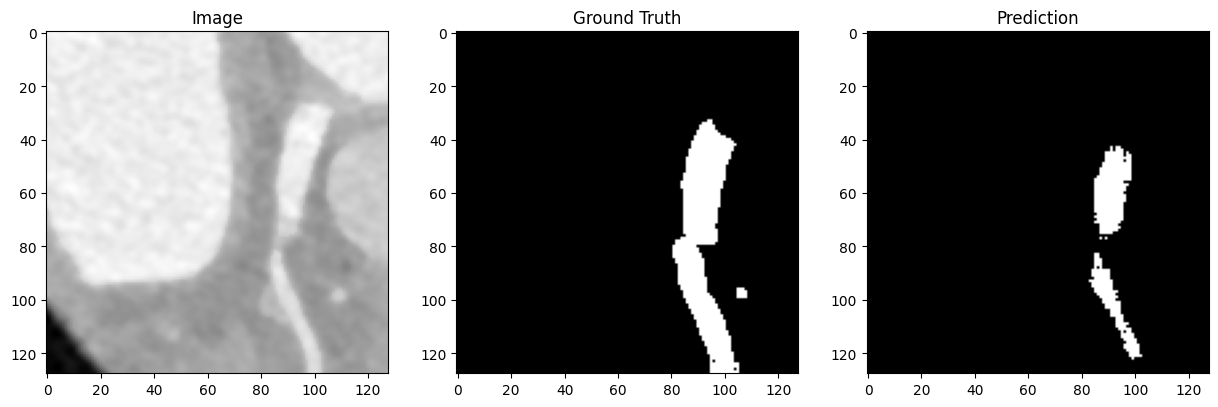

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(image[:,:,best_slice], cmap="gray")
plt.title("Image")

plt.subplot(132)
plt.imshow(label[:,:,best_slice], cmap="gray")
plt.title("Ground Truth")

plt.subplot(133)
plt.imshow(pred[:,:,best_slice], cmap="gray")
plt.title("Prediction")

plt.show()

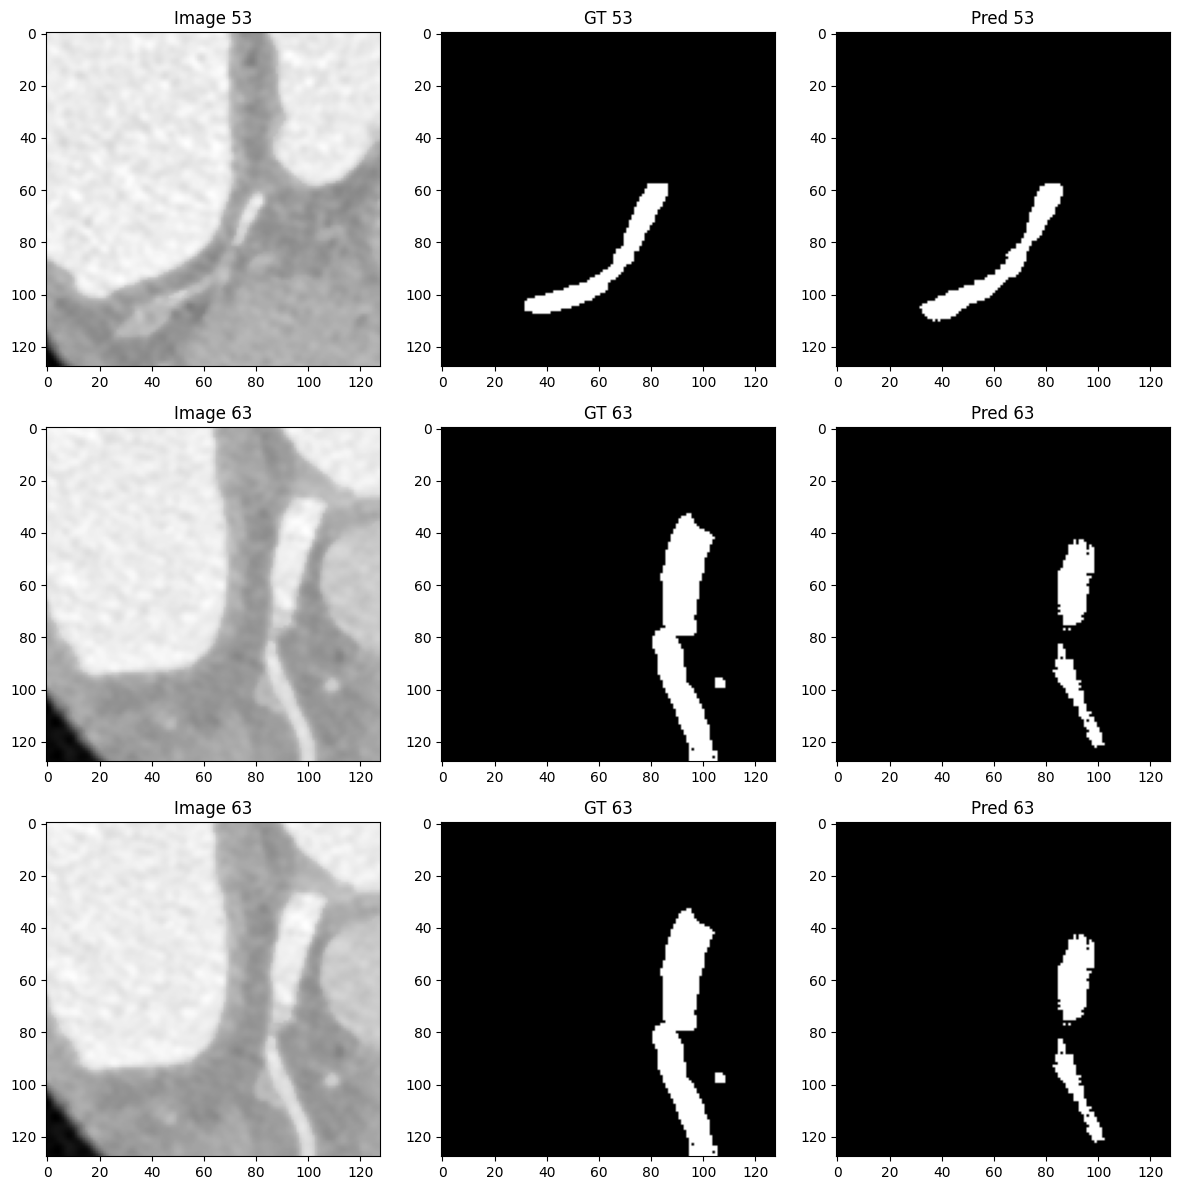

In [67]:
import matplotlib.pyplot as plt

slices = [
    max(best_slice - 10, 0),
    best_slice,
    min(best_slice + 10, label.shape[2]-1)
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, s in enumerate(slices):

    axes[row,0].imshow(image[:,:,s], cmap="gray")
    axes[row,0].set_title(f"Image {s}")

    axes[row,1].imshow(label[:,:,s], cmap="gray")
    axes[row,1].set_title(f"GT {s}")

    axes[row,2].imshow(pred[:,:,s], cmap="gray")
    axes[row,2].set_title(f"Pred {s}")

plt.tight_layout()
plt.show()

In [68]:
model.eval()

with torch.no_grad():

    for i in range(5):

        batch = val_ds[i]

        image = batch["image"].unsqueeze(0).to(device)
        label = batch["label"].unsqueeze(0).to(device)

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        print(f"Sample {i}: Dice = {dice.item():.4f}")

Sample 0: Dice = 0.6458
Sample 1: Dice = 0.0000
Sample 2: Dice = 0.5115
Sample 3: Dice = 0.4429
Sample 4: Dice = 0.0000


In [70]:
for i in range(5):
    sample = val_ds[i]
    print(
        i,
        "label voxels:",
        sample["label"].sum().item()
    )

0 label voxels: 11459.0
1 label voxels: 0.0
2 label voxels: 1997.0
3 label voxels: 756.0
4 label voxels: 492.0


In [71]:
sample_id = 1

sample = val_ds[sample_id]

image = sample["image"].unsqueeze(0).to(device)
label = sample["label"]

with torch.no_grad():
    pred = torch.sigmoid(model(image))
    pred = (pred > 0.5).float().cpu()[0,0]

print("Prediction voxels:", pred.sum())
print("Label voxels:", label.sum())

Prediction voxels: metatensor(7.)
Label voxels: metatensor(0.)


In [72]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in val_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        if label.sum() == 0:
            continue

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection /
            (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

print("Mean Dice:", sum(dice_scores)/len(dice_scores))

Mean Dice: 0.46989687425749643


In [73]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/ImageCAS_Project/imagecas_dice047.pth"
)

In [75]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in val_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        if label.sum() == 0:
            continue

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

val_dice = sum(dice_scores) / len(dice_scores)

print("Validation Dice:", val_dice)

Validation Dice: 0.46989687425749643


In [76]:
model.eval()

dice_scores = []

with torch.no_grad():

    for batch in train_loader:

        image = batch["image"].to(device)
        label = batch["label"].to(device)

        if label.sum() == 0:
            continue

        pred = torch.sigmoid(model(image))
        pred = (pred > 0.5).float()

        intersection = (pred * label).sum()

        dice = (
            2 * intersection
            / (pred.sum() + label.sum() + 1e-8)
        )

        dice_scores.append(dice.item())

train_dice = sum(dice_scores) / len(dice_scores)

print("Train Dice:", train_dice)

Train Dice: 0.6638691812119586


In [77]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/ImageCAS_Project/imagecas_epoch75_val047.pth"
)